In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sesilipirtskhalava/frangieh-dataset/frangieh.h5ad


## GEARS benchmark — frangieh control dataset

Evaluates GEARS against a simple average-perturbation baseline on the Frangieh control single-gene perturbation dataset.

- Dataset: ~27 077 cells · 5 124 genes · 212 single-gene perturbations
- Task: predict gene expression for held-out single-gene perturbations
- Split: random 143 / 16 / 53 train / val / test across perturbations


## 1. Environment setup

In [2]:
%%capture
# Install required packages (output suppressed)
!pip install -q scanpy python-igraph louvain
!pip install -q torch-geometric anndata pytorch-lightning
!pip install -q cell-gears

In [4]:
import scanpy as sc
import random
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Compatibility patch required by some GEARS versions
pd.Series.nonzero = lambda self: self.to_numpy().nonzero()

from gears import PertData, GEARS

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | GPU available: {torch.cuda.is_available()} | device: {DEVICE}")

PyTorch 2.10.0+cu128 | GPU available: True | device: cuda


## 2. Loading the data and processing

In [5]:
from gears import PertData

pert_data = PertData("./data")

pert_data.adata = sc.read_h5ad(
    "/kaggle/input/datasets/sesilipirtskhalava/frangieh-dataset/frangieh.h5ad"
)

print(pert_data.adata)

Downloading...
100%|██████████| 9.46M/9.46M [00:00<00:00, 16.9MiB/s]


AnnData object with n_obs × n_vars = 110188 × 5124
    obs: 'gene', 'condition', 'perturbation', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_5000'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'logNor'


In [6]:
adata = pert_data.adata

control_adata = adata[
    adata.obs["condition"] == "Control"
].copy()

coculture_adata = adata[
    adata.obs["condition"] == "Co-culture"
].copy()

ifng_adata = adata[
    adata.obs["condition"] == "IFNγ"
].copy()

In [7]:
for name, ad in {
    "IFNg": ifng_adata,
    "Co-culture": coculture_adata,
    "Control": control_adata
}.items():

    print("\n", name)
    print("Cells:", ad.n_obs)
    print("Genes:", ad.n_vars)
    print("Perturbations:", ad.obs["perturbation"].nunique())


 IFNg
Cells: 43432
Genes: 5124
Perturbations: 212

 Co-culture
Cells: 39679
Genes: 5124
Perturbations: 212

 Control
Cells: 27077
Genes: 5124
Perturbations: 212


In [8]:
# Keeping only control context
adata = pert_data.adata.copy()

control_adata = adata[
    adata.obs["condition"] == "Control"
].copy()

print(control_adata.shape)
print(control_adata.obs["condition"].value_counts())
print(control_adata.obs["gene"].value_counts().head())


(27077, 5124)
condition
Control    27077
Name: count, dtype: int64
gene
CTRL       480
NT5E       190
RTP4       189
TSC22D3    187
TTLL1      186
Name: count, dtype: int64


In [9]:
# Adding gene_name column required by GEARS
control_adata.var["gene_name"] = control_adata.var_names.astype(str)

print(control_adata.var.columns)
print(control_adata.var[["gene_name"]].head())

Index(['highly_variable', 'means', 'dispersions', 'dispersions_norm',
       'highly_variable_5000', 'gene_name'],
      dtype='object')
          gene_name
gene_name          
STK36         STK36
TMEM45A     TMEM45A
CLIP2         CLIP2
GNAI3         GNAI3
MRI1           MRI1


In [11]:
# GEARS expects obs["condition"] = perturbation identity
control_adata.obs["condition"] = control_adata.obs["perturbation"].astype(str)

# GEARS expects control to be named ctrl
control_adata.obs["condition"] = control_adata.obs["condition"].replace({
    "control": "ctrl",
    "Control": "ctrl",
    "CTRL": "ctrl"
})

# GEARS requires cell_type column
control_adata.obs["cell_type"] = "melanoma_control"

print(control_adata.obs[["perturbation", "condition", "cell_type"]].head())
print(control_adata.obs["condition"].value_counts().head())

              perturbation condition         cell_type
Cell_barcodes                                         
CELL_55512             A2M       A2M  melanoma_control
CELL_41384             A2M       A2M  melanoma_control
CELL_35083             A2M       A2M  melanoma_control
CELL_38432             A2M       A2M  melanoma_control
CELL_34100             A2M       A2M  melanoma_control
condition
ctrl       480
NT5E       190
RTP4       189
TSC22D3    187
FGFR1      186
Name: count, dtype: int64


In [12]:
from scipy import sparse

if not sparse.issparse(control_adata.X):
    control_adata.X = sparse.csr_matrix(control_adata.X)

print(type(control_adata.X))

<class 'scipy.sparse._csr.csr_matrix'>


In [13]:
pert_data_frangieh = PertData("./data")

pert_data_frangieh.new_data_process(
    dataset_name="frangieh_control_de_sparse",
    adata=control_adata,
    skip_calc_de=False
)

Found local copy...
Downloading...
100%|██████████| 559k/559k [00:00<00:00, 1.51MiB/s]
Creating pyg object for each cell in the data...
Creating dataset file...
  0%|          | 0/212 [00:00<?, ?it/s]

A2M


  1%|          | 2/212 [00:01<02:07,  1.64it/s]

ACTA2


  3%|▎         | 6/212 [00:04<02:57,  1.16it/s]

...

 95%|█████████▌| 202/212 [02:18<00:07,  1.39it/s]

TTLL1


 97%|█████████▋| 205/212 [02:20<00:04,  1.51it/s]

UCN2


100%|██████████| 212/212 [02:24<00:00,  1.47it/s]
Done!
Saving new dataset pyg object at ./data/frangieh_control_de_sparse/data_pyg/cell_graphs.pkl
Done!


## 3. Train / val / test split

In [14]:
# Creating perturbation-level split
all_perturbations = sorted([
    p for p in control_adata.obs["condition"].unique()
    if p != "ctrl"
])

train_val_perturbations, test_perturbations = train_test_split(
    all_perturbations,
    test_size=0.25,
    random_state=SEED,
    shuffle=True
)

train_perturbations, val_perturbations = train_test_split(
    train_val_perturbations,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

print("Total perturbations:", len(all_perturbations))
print("Train:", len(train_perturbations))
print("Val:", len(val_perturbations))
print("Test:", len(test_perturbations))

Total perturbations: 211
Train: 142
Val: 16
Test: 53


In [15]:
# Assigning manual perturbation-level split to GEARS
pert_data_frangieh.split = "manual_random_single_pert"

pert_data_frangieh.set2conditions = {
    "train": train_perturbations + ["ctrl"],
    "val": val_perturbations,
    "test": test_perturbations,
}

print(pert_data_frangieh.set2conditions.keys())
print("Train example:", pert_data_frangieh.set2conditions["train"][:5])
print("Val example:", pert_data_frangieh.set2conditions["val"][:5])
print("Test example:", pert_data_frangieh.set2conditions["test"][:5])

dict_keys(['train', 'val', 'test'])
Train example: ['HLA-B', 'CITED1', 'MT2A', 'CD58', 'VAT1']
Val example: ['DLL3', 'DDX17', 'SMAD4', 'ILF2', 'P2RX4']
Test example: ['CTSB', 'TGFB1', 'DDR1', 'TPRKB', 'CHCHD2']


In [16]:
import pickle

split_dict_path = "./data/frangieh_control_manual_split.pkl"

with open(split_dict_path, "wb") as f:
    pickle.dump(pert_data_frangieh.set2conditions, f)

print(split_dict_path)

./data/frangieh_control_manual_split.pkl


In [17]:
# Preparing GEARS split
pert_data_frangieh.prepare_split(
    split="custom",
    seed=SEED,
    split_dict_path=split_dict_path
)

pert_data_frangieh.get_dataloader(
    batch_size=32,
    test_batch_size=32
)

Creating dataloaders....
Done!


## 4. Ground-truth centroids and baseline

In [18]:
# Ground-truth centroids and average perturbation baseline

X = control_adata.X.toarray() if hasattr(control_adata.X, "toarray") else control_adata.X

gene_names = control_adata.var_names
conditions = control_adata.obs["condition"].values

pert_mask = conditions != "ctrl"

df_pert = pd.DataFrame(
    X[pert_mask],
    columns=gene_names
)

df_pert["condition"] = conditions[pert_mask]

ground_truth_centroids = (
    df_pert.groupby("condition")[gene_names]
    .mean()
)

# Reference / baseline = average of training perturbation centroids
reference = ground_truth_centroids.loc[train_perturbations].mean(axis=0).values

print("Ground-truth centroids:", ground_truth_centroids.shape)
print("Reference vector shape:", reference.shape)

Ground-truth centroids: (212, 5124)
Reference vector shape: (5124,)


## 5. Train GEARS

In [19]:
gears_model = GEARS(
    pert_data_frangieh,
    device=DEVICE
)

gears_model.model_initialize(
    hidden_size=64
)

Downloading...
100%|██████████| 60.7M/60.7M [00:02<00:00, 25.4MiB/s]
Extracting tar file...
Done!


In [20]:
gears_model.train(
    epochs=20
)

Start Training...
Epoch 1 Step 1 Train Loss: 1.1093
Epoch 1 Step 51 Train Loss: 1.1660
Epoch 1 Step 101 Train Loss: 1.2005
Epoch 1 Step 151 Train Loss: 1.1178
Epoch 1 Step 201 Train Loss: 1.1841
Epoch 1 Step 251 Train Loss: 1.0784
Epoch 1 Step 301 Train Loss: 1.1964
Epoch 1 Step 351 Train Loss: 1.0668
Epoch 1 Step 401 Train Loss: 1.0071
Epoch 1 Step 451 Train Loss: 1.1942
Epoch 1 Step 501 Train Loss: 1.0049
Epoch 1 Step 551 Train Loss: 1.2177
Epoch 1: Train Overall MSE: 0.0054 Validation Overall MSE: 0.0048. 
Train Top 20 DE MSE: 0.0191 Validation Top 20 DE MSE: 0.0158. 
Epoch 2 Step 1 Train Loss: 1.0881
Epoch 2 Step 51 Train Loss: 1.1395
Epoch 2 Step 101 Train Loss: 1.1033
Epoch 2 Step 151 Train Loss: 1.0005
Epoch 2 Step 201 Train Loss: 0.9278
Epoch 2 Step 251 Train Loss: 1.2096
Epoch 2 Step 301 Train Loss: 1.1518
Epoch 2 Step 351 Train Loss: 1.0505
Epoch 2 Step 401 Train Loss: 1.2123
Epoch 2 Step 451 Train Loss: 1.1266
Epoch 2 Step 501 Train Loss: 1.1038
Epoch 2 Step 551 Train Loss: 

In [21]:
predictable_test_perturbations = [
    p for p in test_perturbations
    if p in gears_model.pert_list
]

missing_test_perturbations = [
    p for p in test_perturbations
    if p not in gears_model.pert_list
]

print("Original test perturbations:", len(test_perturbations))
print("Predictable test perturbations:", len(predictable_test_perturbations))
print("Missing from GEARS graph:", len(missing_test_perturbations))

Original test perturbations: 53
Predictable test perturbations: 40
Missing from GEARS graph: 13


## 6. Predict on test perturbations

In [22]:
test_input = [[p] for p in predictable_test_perturbations]

predictions = gears_model.predict(test_input)

print("Number of predictions:", len(predictions))
print("Example keys:", list(predictions.keys())[:10])

Number of predictions: 40
Example keys: ['CTSB', 'TGFB1', 'DDR1', 'TPRKB', 'CHCHD2', 'IDH2', 'RRS1', 'UBC', 'PFDN4', 'ISYNA1']


In [24]:
# GEARS predictions
gears_pred_dict = {}

for pert in predictable_test_perturbations:
    gears_pred_dict[pert] = predictions[pert]

# Average perturbation baseline
avg_pred_dict = {}

for pert in predictable_test_perturbations:
    avg_pred_dict[pert] = reference

# Ground truth
truth_dict = {}

for pert in predictable_test_perturbations:
    truth_dict[pert] = ground_truth_centroids.loc[pert].values

print("GEARS predictions:", len(gears_pred_dict))
print("Baseline predictions:", len(avg_pred_dict))
print("Ground truths:", len(truth_dict))

GEARS predictions: 40
Baseline predictions: 40
Ground truths: 40


## 7. Evaluation

GEARS was evaluated on the held-out test perturbations. Due to limitations of the perturbation graph, predictions could be generated for 40 of the 53 test perturbations. All evaluation metrics were therefore computed on these 40 predictable perturbations.

The average perturbation baseline was defined as the mean centroid of all training perturbations and was used as a constant baseline prediction. The same vector was used as the reference for PearsonΔ calculations.

In [25]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# ----------------------------
# Per-perturbation metrics
# ----------------------------
rows = []

for pert in predictable_test_perturbations:

    y_true = truth_dict[pert]
    y_gears = gears_pred_dict[pert]
    y_avg = avg_pred_dict[pert]

    rows.append({
        "perturbation": pert,
        "gears_rmse": np.sqrt(mean_squared_error(y_true, y_gears)),
        "avg_rmse": np.sqrt(mean_squared_error(y_true, y_avg)),
        "gears_pearson": pearsonr(y_true, y_gears)[0],
        "avg_pearson": pearsonr(y_true, y_avg)[0],
        "gears_pearson_delta": pearsonr(
            y_true - reference,
            y_gears - reference
        )[0]
    })

results_df = pd.DataFrame(rows)


# ----------------------------
# Centroid accuracy
# ----------------------------
def centroid_accuracy(pred_dict, truth_dict):
    perts = list(pred_dict.keys())
    scores = []

    for p in perts:
        d_correct = np.linalg.norm(pred_dict[p] - truth_dict[p])

        d_others = [
            np.linalg.norm(pred_dict[p] - truth_dict[q])
            for q in perts
            if q != p
        ]

        scores.append(np.mean([d_correct < d for d in d_others]))

    return np.mean(scores)


# ----------------------------
# Aggregate summary table
# ----------------------------
summary_table = pd.DataFrame({
    "GEARS": {
        "RMSE": results_df["gears_rmse"].mean(),
        "Pearson (raw)": results_df["gears_pearson"].mean(),
        "Pearson (delta)": results_df["gears_pearson_delta"].mean(),
        "Centroid accuracy": centroid_accuracy(gears_pred_dict, truth_dict)
    },
    "Average perturbation baseline": {
        "RMSE": results_df["avg_rmse"].mean(),
        "Pearson (raw)": results_df["avg_pearson"].mean(),
        "Pearson (delta)": np.nan,
        "Centroid accuracy": centroid_accuracy(avg_pred_dict, truth_dict)
    }
})

print("=== Aggregate summary ===")
display(summary_table.round(4))


# ----------------------------
# Top 15 perturbations by GEARS Pearson
# ----------------------------
top15_table = (
    results_df
    .sort_values("gears_pearson", ascending=False)
    [
        [
            "perturbation",
            "gears_rmse",
            "avg_rmse",
            "gears_pearson",
            "avg_pearson",
            "gears_pearson_delta"
        ]
    ]
    .head(15)
    .round(4)
)

print("=== Top 15 perturbations by GEARS Pearson ===")
display(top15_table)

=== Aggregate summary ===


,GEARS,Average perturbation baseline
RMSE,0.0586,0.0509
Pearson (raw),0.9882,0.9905
Pearson (delta),0.0070,NaN
Centroid accuracy,0.5051,0.5000


=== Top 15 perturbations by GEARS Pearson ===


,perturbation,gears_rmse,avg_rmse,gears_pearson,avg_pearson,gears_pearson_delta
8,PFDN4,0.0421,0.0348,0.9945,0.9962,0.0896
5,IDH2,0.0426,0.0339,0.9943,0.9965,0.0347
25,SP100,0.0437,0.0372,0.9941,0.9958,0.0610
1,TGFB1,0.0439,0.0344,0.9940,0.9963,0.0004
20,TP53,0.0444,0.0356,0.9938,0.9961,-0.0042
24,KLF4,0.0450,0.0367,0.9937,0.9958,0.0398
21,VDAC2,0.0450,0.0368,0.9936,0.9957,0.0249
4,CHCHD2,0.0454,0.0351,0.9936,0.9962,-0.0422
33,RNF213,0.0465,0.0367,0.9934,0.9958,-0.0020
27,SDCBP,0.0463,0.0366,0.9934,0.9958,0.0367


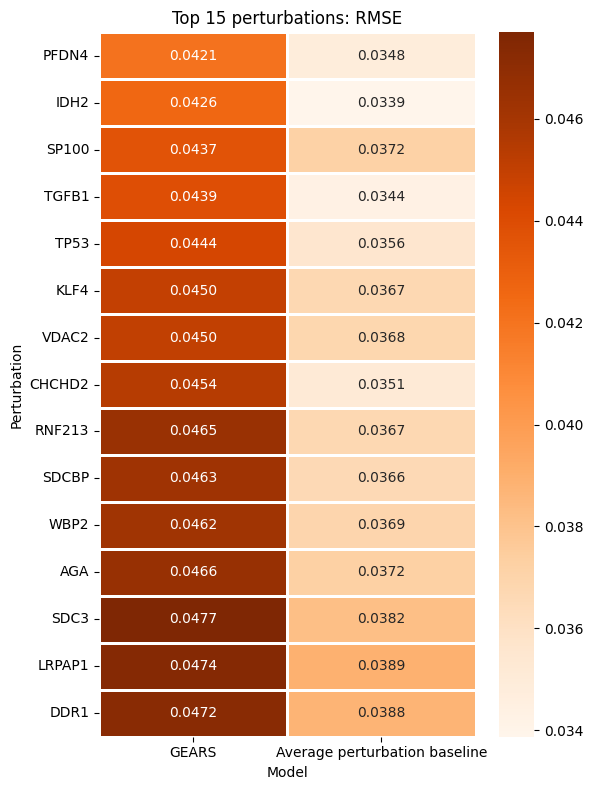

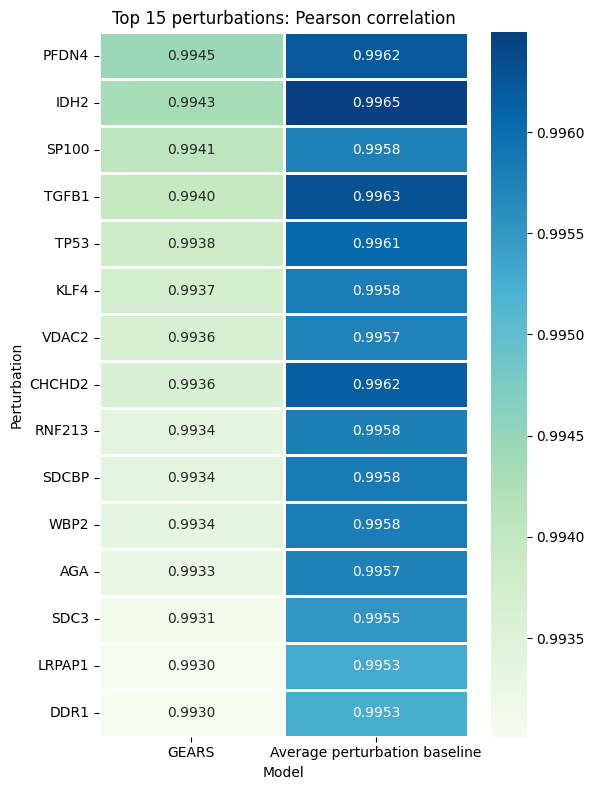

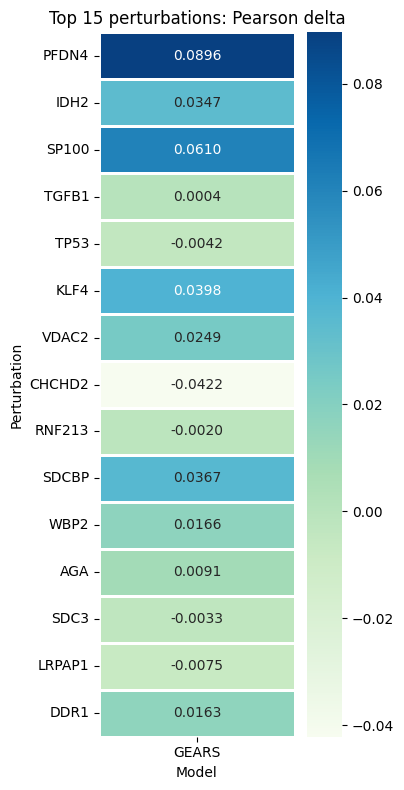

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
  
top15_perts = top15_table["perturbation"].tolist()

top15_metrics = results_df[
    results_df["perturbation"].isin(top15_perts)
].set_index("perturbation").loc[top15_perts]

rmse_heatmap = top15_metrics[
    ["gears_rmse", "avg_rmse"]
].rename(columns={
    "gears_rmse": "GEARS",
    "avg_rmse": "Average perturbation baseline"
})

plt.figure(figsize=(6, 8))
sns.heatmap(rmse_heatmap, annot=True, fmt=".4f", cmap="Oranges", linewidths=2, linecolor="white")
plt.title("Top 15 perturbations: RMSE")
plt.ylabel("Perturbation")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

pearson_heatmap = top15_metrics[
    ["gears_pearson", "avg_pearson"]
].rename(columns={
    "gears_pearson": "GEARS",
    "avg_pearson": "Average perturbation baseline"
})

plt.figure(figsize=(6, 8))
sns.heatmap(pearson_heatmap, annot=True, fmt=".4f", cmap="GnBu", linewidths=2, linecolor="white")
plt.title("Top 15 perturbations: Pearson correlation")
plt.ylabel("Perturbation")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

pearson_delta_heatmap = top15_metrics[
    ["gears_pearson_delta"]
].rename(columns={
    "gears_pearson_delta": "GEARS"
})

plt.figure(figsize=(4, 8))
sns.heatmap(pearson_delta_heatmap, annot=True, fmt=".4f", cmap="GnBu", linewidths=2, linecolor="white")
plt.title("Top 15 perturbations: Pearson delta")
plt.ylabel("Perturbation")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

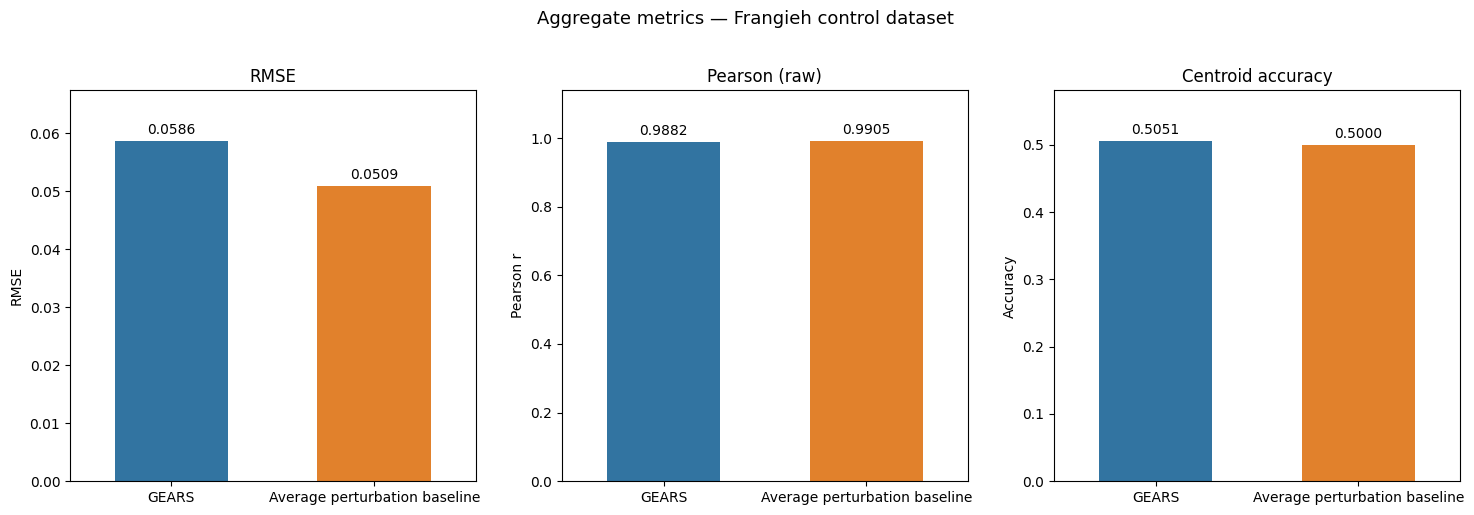

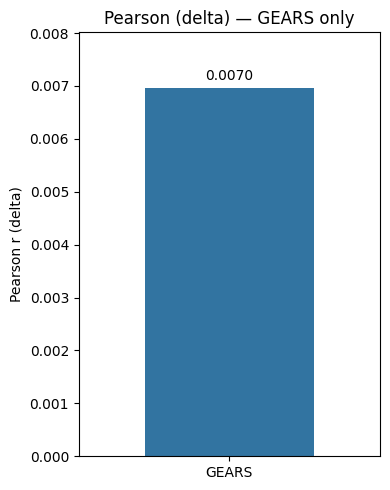

In [27]:
PALETTE = {
    "GEARS": "#1f77b4",
    "Average perturbation baseline": "#ff7f0e"
}

def slim_barplot(ax, data, x, y, palette, title, ylabel):
    sns.barplot(data=data, x=x, y=y, palette=palette, ax=ax)

    for bar in ax.patches:
        w = bar.get_width()
        bar.set_width(w * 0.7)
        bar.set_x(bar.get_x() + w * 0.15)

    ymax = data[y].dropna().max()
    ax.set_ylim(0, ymax * 1.15)

    for c in ax.containers:
        ax.bar_label(c, fmt="%.4f", padding=3)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")


summary_long = (
    summary_table.T
    .reset_index()
    .rename(columns={"index": "model"})
)

# ----------------------------
# RMSE, Pearson, Centroid Accuracy
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, ylabel in zip(
    axes,
    ["RMSE", "Pearson (raw)", "Centroid accuracy"],
    ["RMSE", "Pearson r", "Accuracy"]
):
    slim_barplot(
        ax,
        summary_long,
        x="model",
        y=metric,
        palette=PALETTE,
        title=metric,
        ylabel=ylabel
    )

plt.suptitle(
    "Aggregate metrics — Frangieh control dataset",
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()


# ----------------------------
# Pearson delta (GEARS only)
# ----------------------------
gears_only = summary_long[
    summary_long["model"] == "GEARS"
]

fig, ax = plt.subplots(figsize=(4, 5))

slim_barplot(
    ax,
    gears_only,
    x="model",
    y="Pearson (delta)",
    palette={"GEARS": "#1f77b4"},
    title="Pearson (delta) — GEARS only",
    ylabel="Pearson r (delta)"
)

plt.tight_layout()
plt.show()